# Daily data

In [35]:
import pandas as pd
import seaborn as sns


In [31]:
df = pd.read_csv('../data/intermediate/monthly.csv')
df = df.drop(columns=["Unnamed: 0"])
df

,Region,Date,slavic_name,non_slavic_name,pmc,drafted,volunteers,prisoners,contract,total,...,region_type,region,position,governor,start,end,birth_year,insider,approved,nat_rep
0,Алтайский край,2022-02-01,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
1,Алтайский край,2022-03-01,33.0,2.0,0.0,0.0,0.0,0.0,35.0,35.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
2,Алтайский край,2022-04-01,30.0,2.0,0.0,0.0,2.0,0.0,30.0,32.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
3,Алтайский край,2022-05-01,57.0,5.0,0.0,0.0,2.0,0.0,60.0,62.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
4,Алтайский край,2022-06-01,31.0,3.0,0.0,0.0,4.0,0.0,30.0,34.0,...,Kraya (regions),Altay,Heads of the administration/governors,Viktor Tomenko,2018-05-30,2025-08-08,1971.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,Ярославская область,2025-03-01,4.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,...,Oblasti (provinces),Yaroslavl,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0
3551,Ярославская область,2025-04-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,Oblasti (provinces),Yaroslavl,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0
3552,Ярославская область,2025-05-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,Oblasti (provinces),Yaroslavl,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0
3553,Ярославская область,2025-06-01,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,Oblasti (provinces),Yaroslavl,"Head of the administration (from Dec 1995, gov...",Mikhail Yevrayev,2021-10-12,2025-08-08,1971.0,1.0,1.0,0.0


In [45]:
data = df.groupby('Date').agg(
    count = ('total', 'sum'),
    slavic = ('slavic_name', 'sum')
).reset_index()

df_melted = data.melt(id_vars='Date', 
                    value_vars=['count', 'slavic'],
                    var_name='Category', 
                    value_name='Count')
df_melted

,Date,Category,Count
0,2022-02-01,count,600.0
1,2022-03-01,count,1884.0
2,2022-04-01,count,1078.0
3,2022-05-01,count,1240.0
4,2022-06-01,count,1181.0
...,...,...,...
79,2025-03-01,slavic,770.0
80,2025-04-01,slavic,367.0
81,2025-05-01,slavic,148.0
82,2025-06-01,slavic,95.0


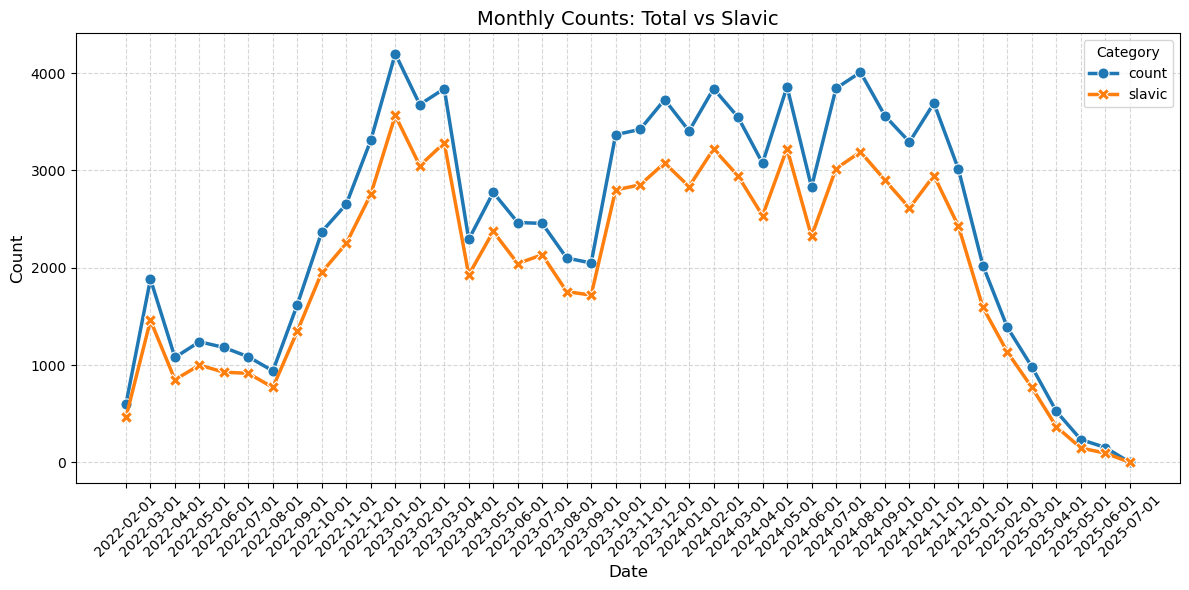

In [47]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, 
             x='Date', 
             y='Count', 
             hue='Category',  # Now this column exists
             style='Category', # Different line styles
             markers=True, 
             dashes=False,
             linewidth=2.5,
             markersize=8)

# Customize the plot
plt.title('Monthly Counts: Total vs Slavic', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [55]:
data = df[['Region', 'Date', 'total', 'population']].copy()
data['fatalities_per_100k'] = (data['total'] / data['population']) * 100000
data

,Region,Date,total,population,fatalities_per_100k
0,Алтайский край,2022-02-01,1.0,2142900.0,0.046666
1,Алтайский край,2022-03-01,35.0,2142900.0,1.633301
2,Алтайский край,2022-04-01,32.0,2142900.0,1.493303
3,Алтайский край,2022-05-01,62.0,2142900.0,2.893275
4,Алтайский край,2022-06-01,34.0,2142900.0,1.586635
...,...,...,...,...,...
3550,Ярославская область,2025-03-01,5.0,1200100.0,0.416632
3551,Ярославская область,2025-04-01,NaN,1200100.0,NaN
3552,Ярославская область,2025-05-01,NaN,1200100.0,NaN
3553,Ярославская область,2025-06-01,NaN,1200100.0,NaN


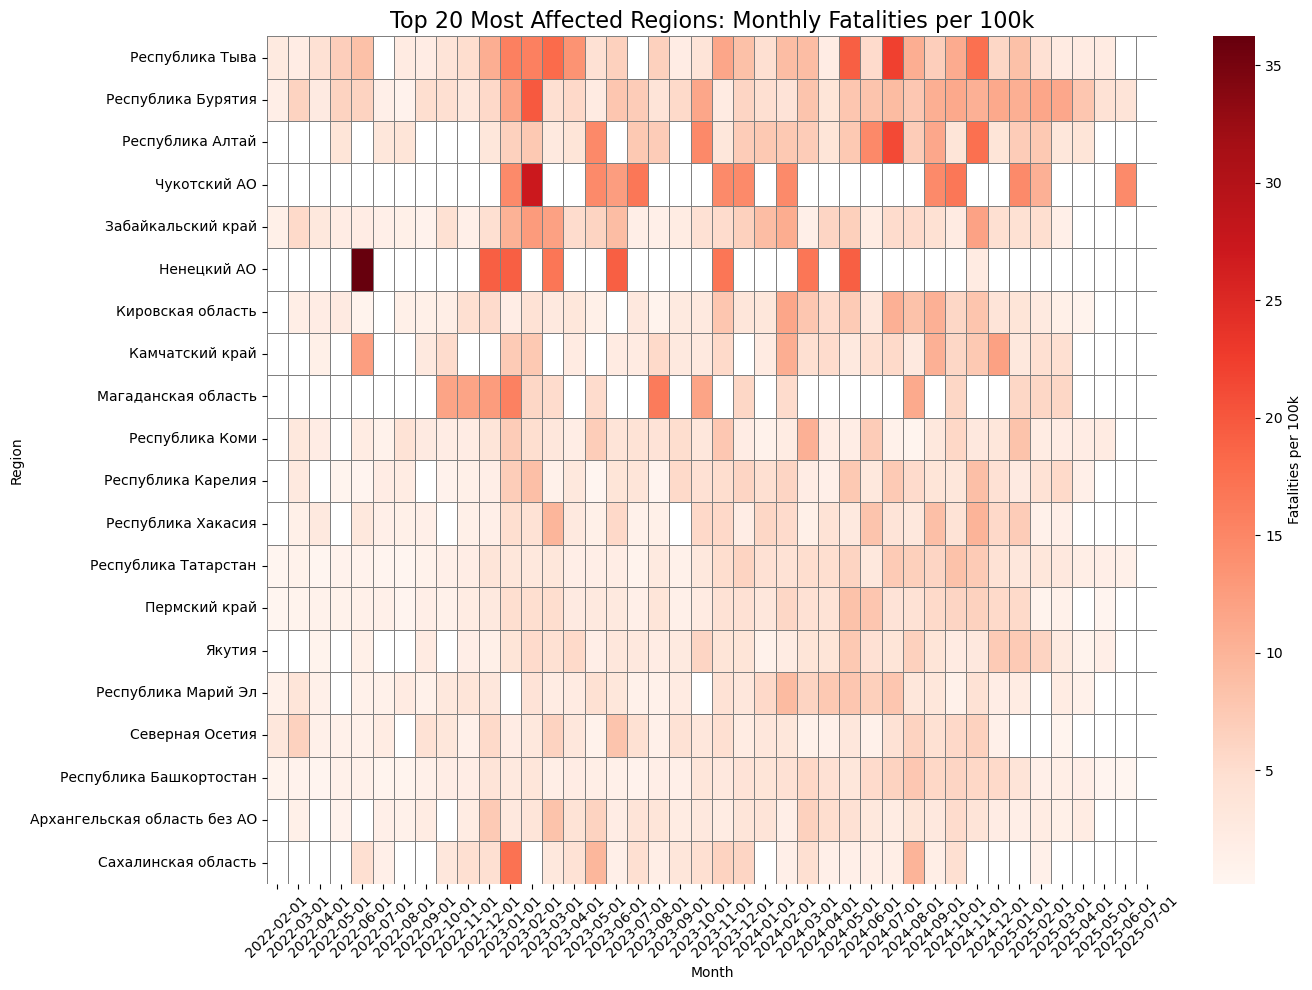

In [58]:
heatmap_data = data.pivot_table(
    index='Region',
    columns='Date',
    values='fatalities_per_100k'  # Sum if there are multiple entries per region-month
)

top_regions = heatmap_data.sum(axis=1).sort_values(ascending=False).head(20).index
heatmap_data_top = heatmap_data.loc[top_regions]

# Plot the heatmap
plt.figure(figsize=(14, 10))  # Reduced height for fewer rows
sns.heatmap(
    heatmap_data_top,
    cmap='Reds',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Fatalities per 100k'}
)

plt.title('Top 20 Most Affected Regions: Monthly Fatalities per 100k', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

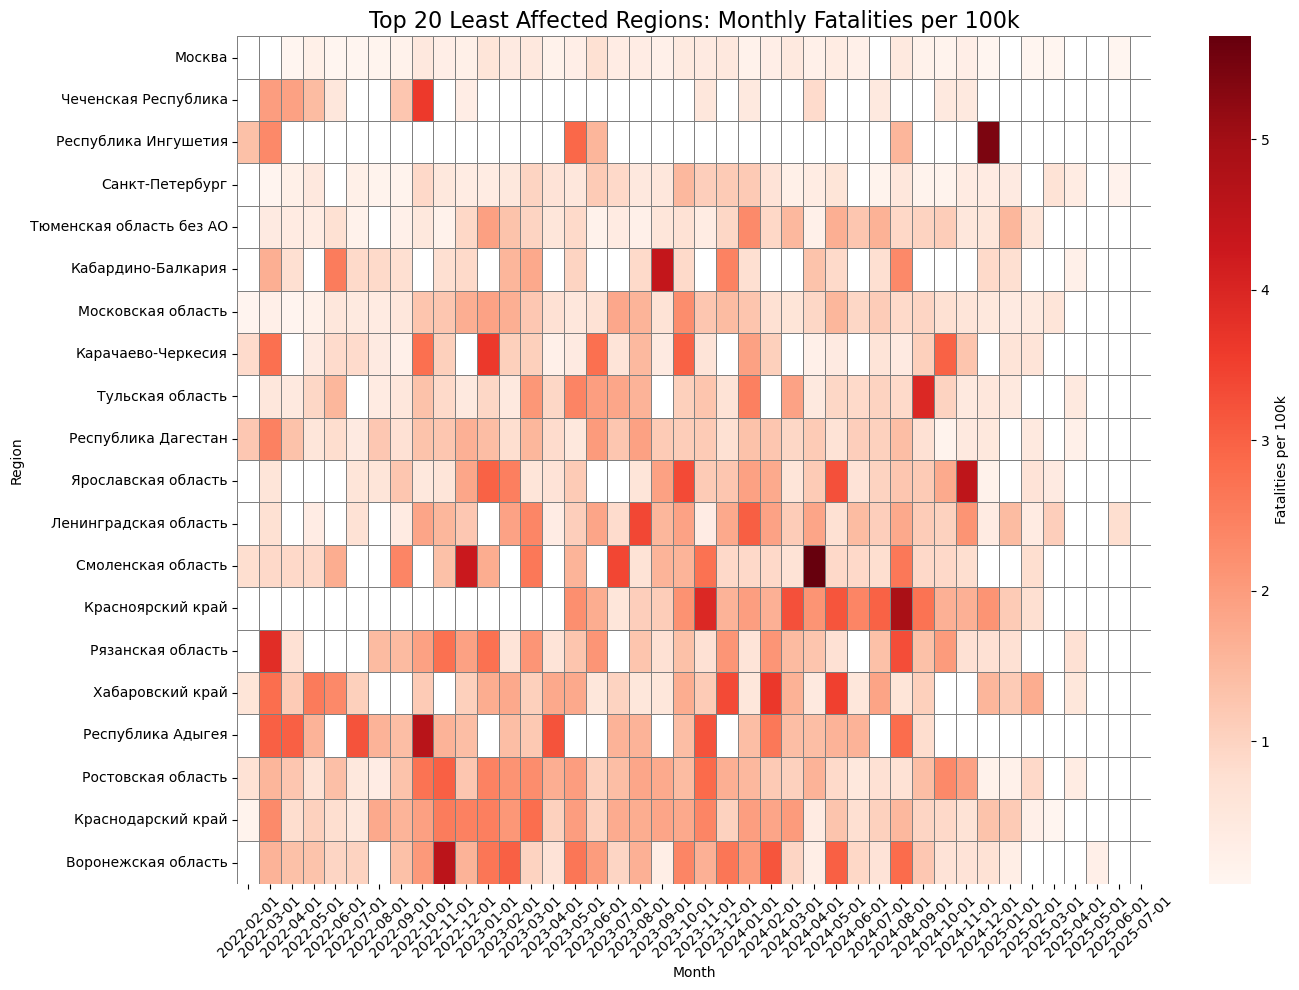

In [59]:
heatmap_data = data.pivot_table(
    index='Region',
    columns='Date',
    values='fatalities_per_100k'  # Sum if there are multiple entries per region-month
)

bottom_regions = heatmap_data.sum(axis=1).sort_values(ascending=True).head(20).index
heatmap_data_bottom = heatmap_data.loc[bottom_regions]

# Plot the heatmap
plt.figure(figsize=(14, 10))  # Reduced height for fewer rows
sns.heatmap(
    heatmap_data_bottom,
    cmap='Reds',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Fatalities per 100k'}
)

plt.title('Top 20 Least Affected Regions: Monthly Fatalities per 100k', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Robert_Beta\AppData\Local\Temp\ipykernel_1252\2133762038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=marriage_data_sorted, y='Region', x='Excessive Marriages', palette='magma')


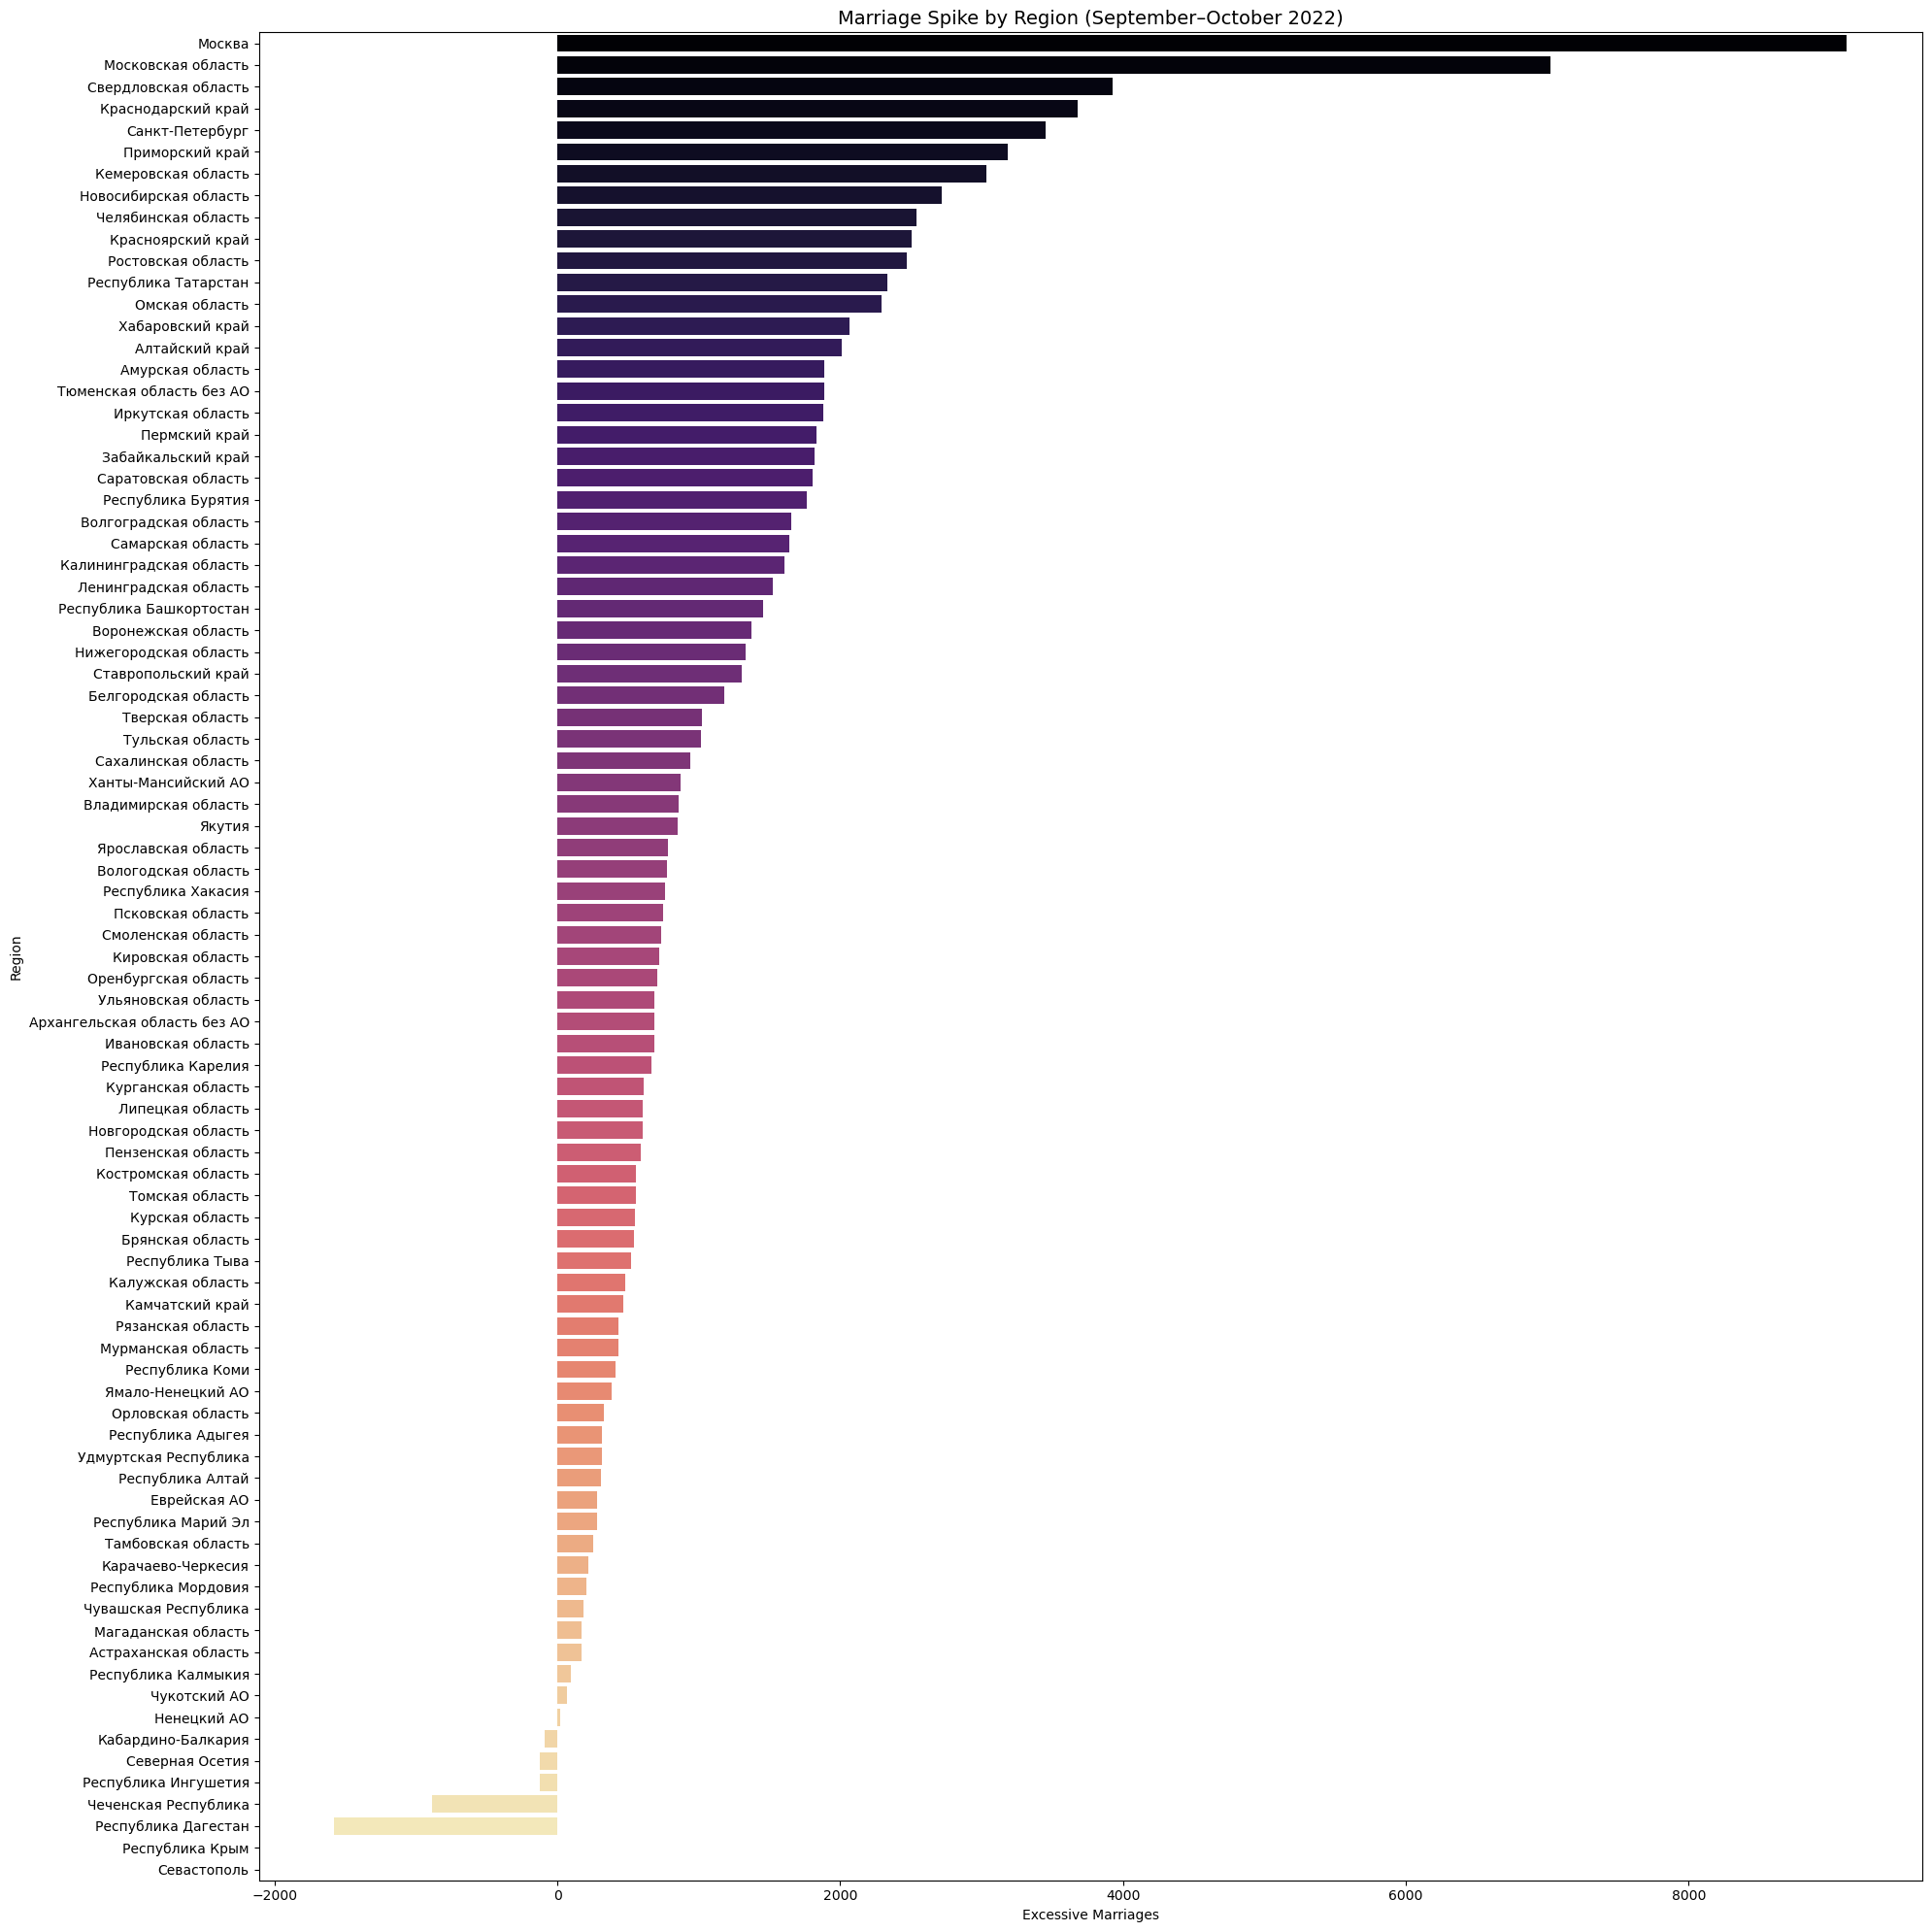

In [65]:
marriage_data = df[['Region', 'Excessive Marriages', 'ex_nup_per100k']].drop_duplicates()
marriage_data_sorted = marriage_data.sort_values(by='Excessive Marriages', ascending=False)

plt.figure(figsize=(20, 20))
sns.barplot(data=marriage_data_sorted, y='Region', x='Excessive Marriages', palette='magma')
plt.title('Marriage Spike by Region (September–October 2022)', fontsize=14)
plt.xlabel('Excessive Marriages')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


C:\Users\Robert_Beta\AppData\Local\Temp\ipykernel_1252\3913041464.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=marriage_data_sorted, y='Region', x='ex_nup_per100k', palette='magma')


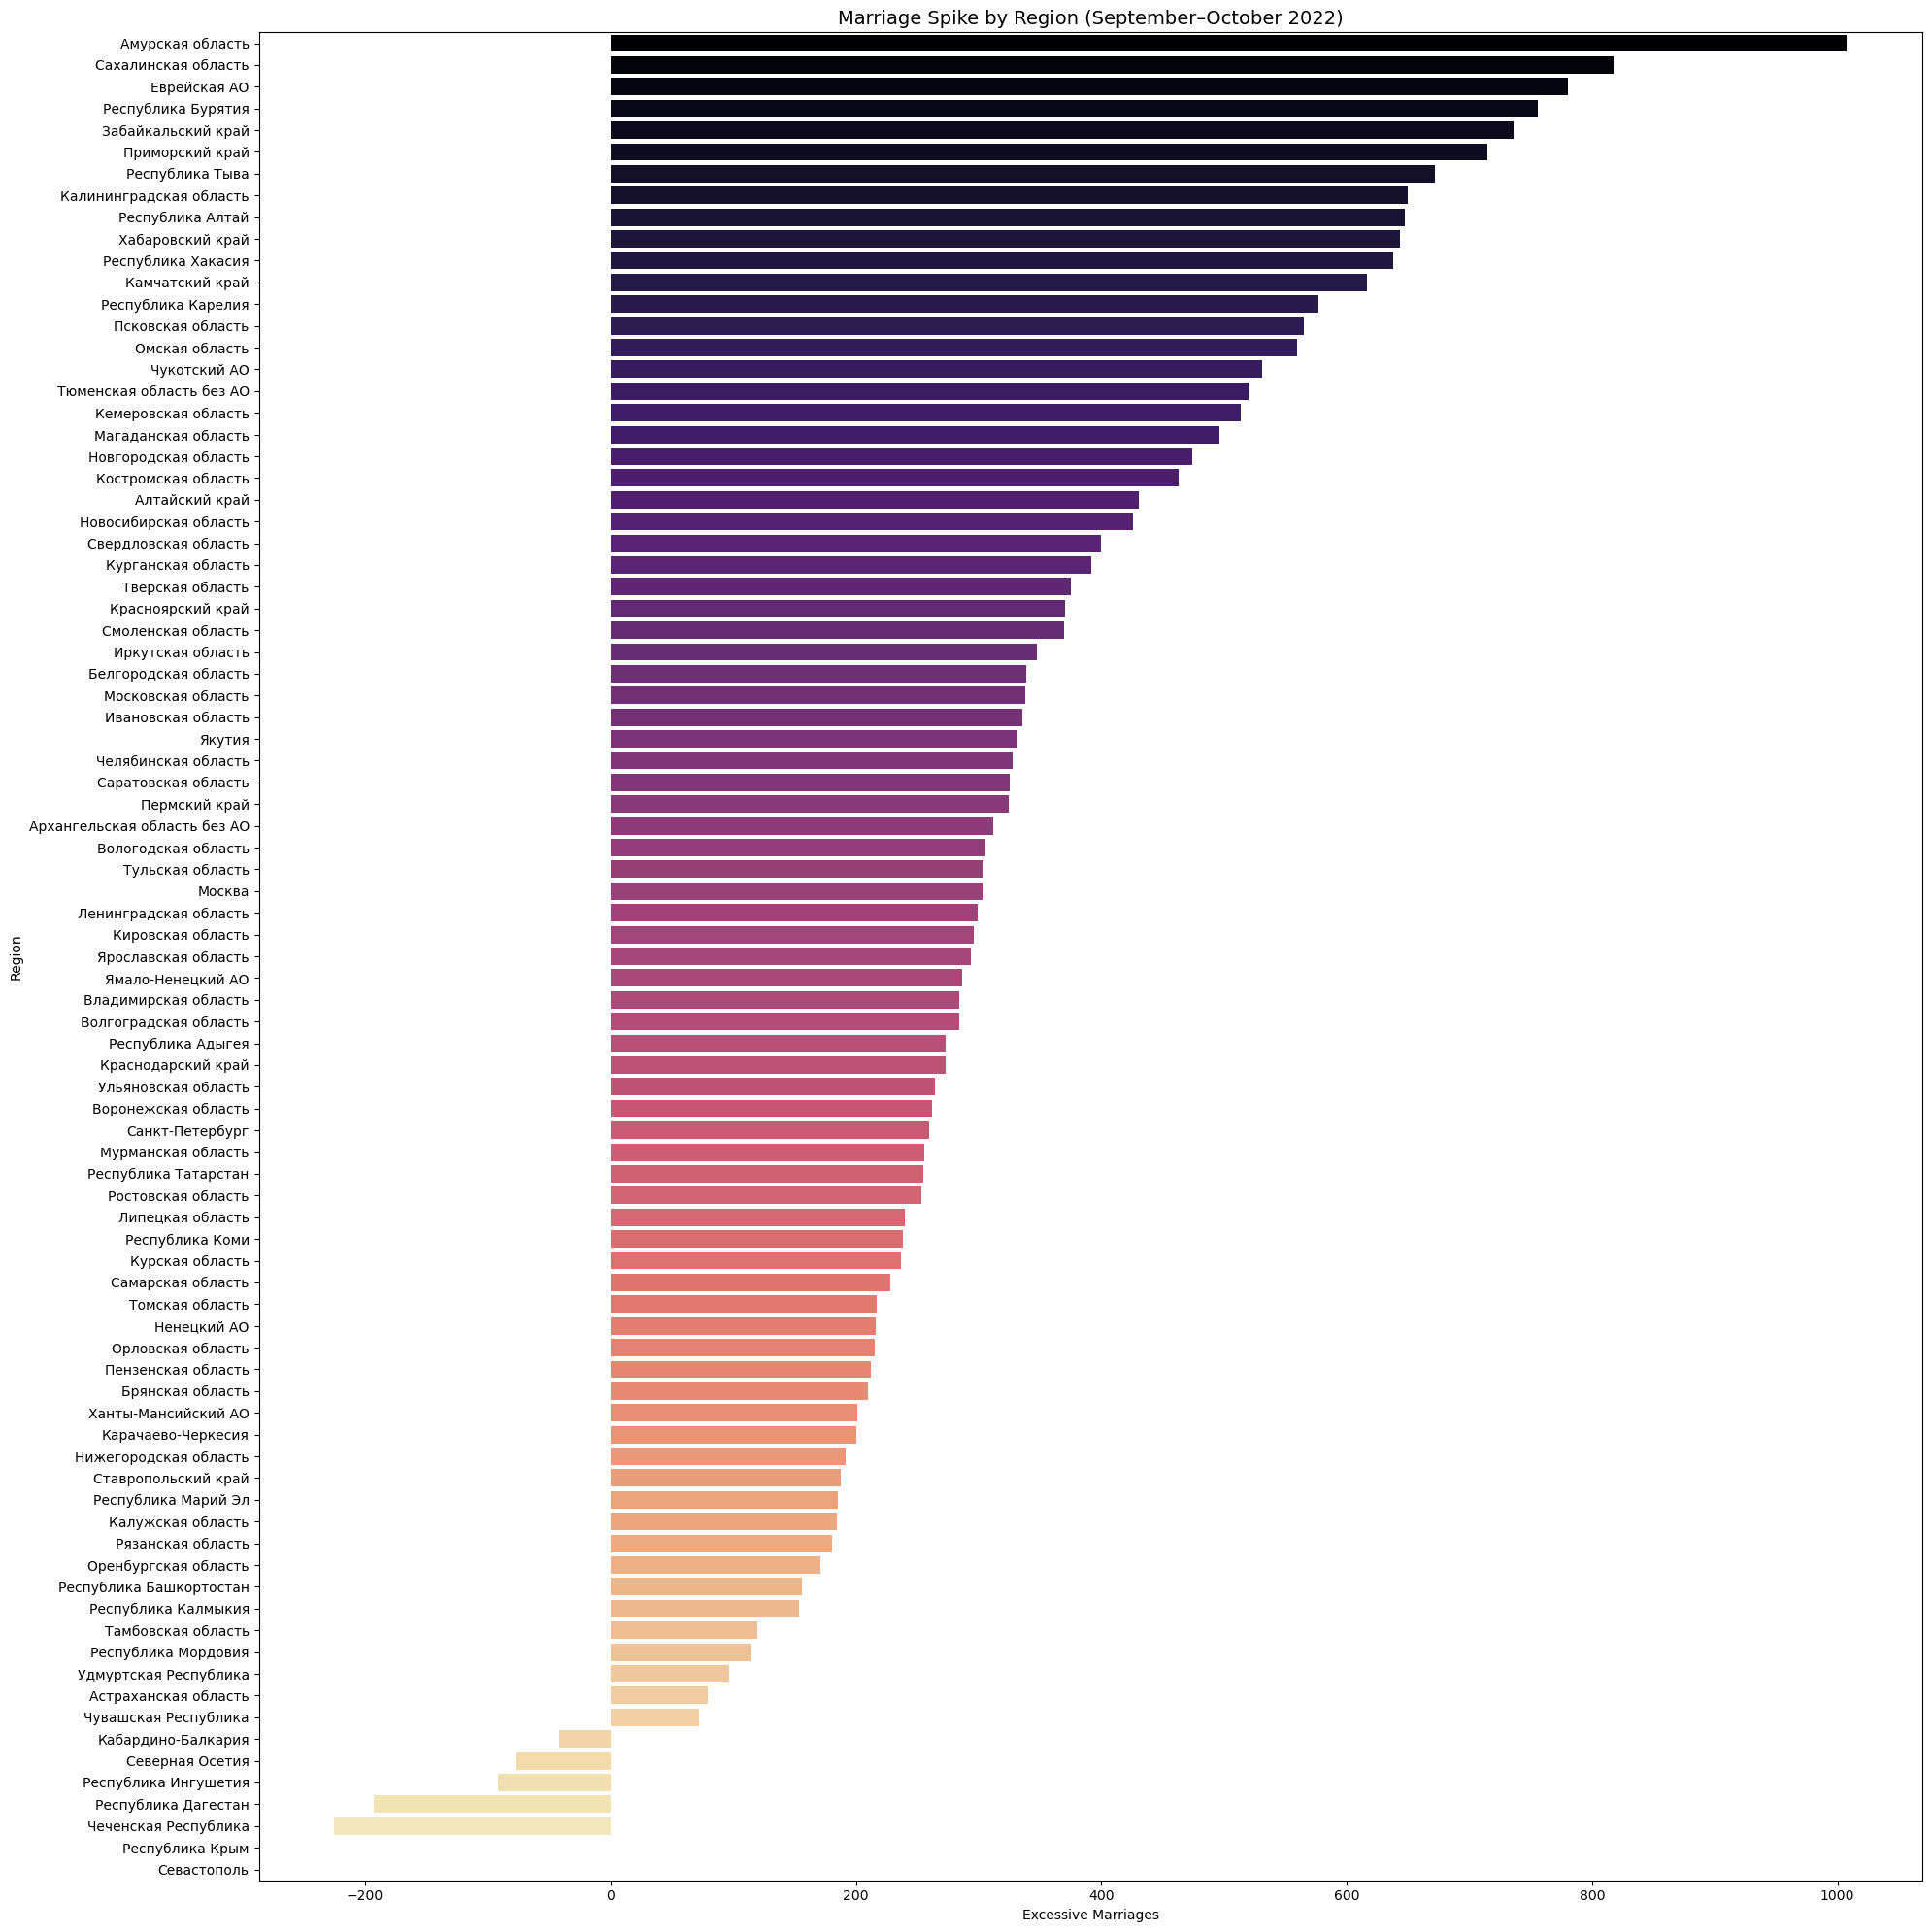

In [67]:
marriage_data_sorted = marriage_data.sort_values(by='ex_nup_per100k', ascending=False)

plt.figure(figsize=(20, 20))
sns.barplot(data=marriage_data_sorted, y='Region', x='ex_nup_per100k', palette='magma')
plt.title('Marriage Spike by Region (September–October 2022)', fontsize=14)
plt.xlabel('Excessive Marriages')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


In [ ]:
post_mob = df[(df['Date'] >= '2022-11-01')].copy()
post_mob['drafted_per_100k'] = (post_mob['drafted'] / post_mob['population']) * 100000
fatality_data = post_mob.groupby('Region').agg({
    'drafted': 'sum',
    'drafted_per_100k': 'sum'
}).reset_index()

pre_mob = df[(df['Date'] >= '2022-02-01') & (df['Date'] <= '2022-08-31')].copy()
pre_mob['fatalities_per_100k'] = (pre_mob['total'] / pre_mob['population']) * 100000
pre_fatality = pre_mob.groupby('Region').agg({
    'fatalities_per_100k': 'sum',
    'total': 'sum'
}).reset_index().rename(columns={
    'fatalities_per_100k': 'pre_total_per_100k',
    'total': 'pre_total_abs'
})

merged = pd.merge(marriage_data, fatality_data, on='Region')
merged = pd.merge(merged, pre_fatality, on='Region')
merged


,Region,Excessive Marriages,ex_nup_per100k,drafted,drafted_per_100k
0,Алтайский край,2007.6,430.387834,171.0,7.979840
1,Амурская область,1890.4,1007.471834,53.0,6.974602
2,Архангельская область без АО,684.2,311.861873,186.0,18.400356
3,Астраханская область,172.8,79.122691,83.0,8.698386
4,Белгородская область,1182.4,338.946125,139.0,9.111767
...,...,...,...,...,...
80,Чувашская Республика,185.6,71.876973,93.0,7.891053
81,Чукотский АО,69.4,531.027623,19.0,39.707419
82,Якутия,850.0,331.501624,236.0,23.654405
83,Ямало-Hенецкий АО,386.2,286.351942,25.0,4.884721


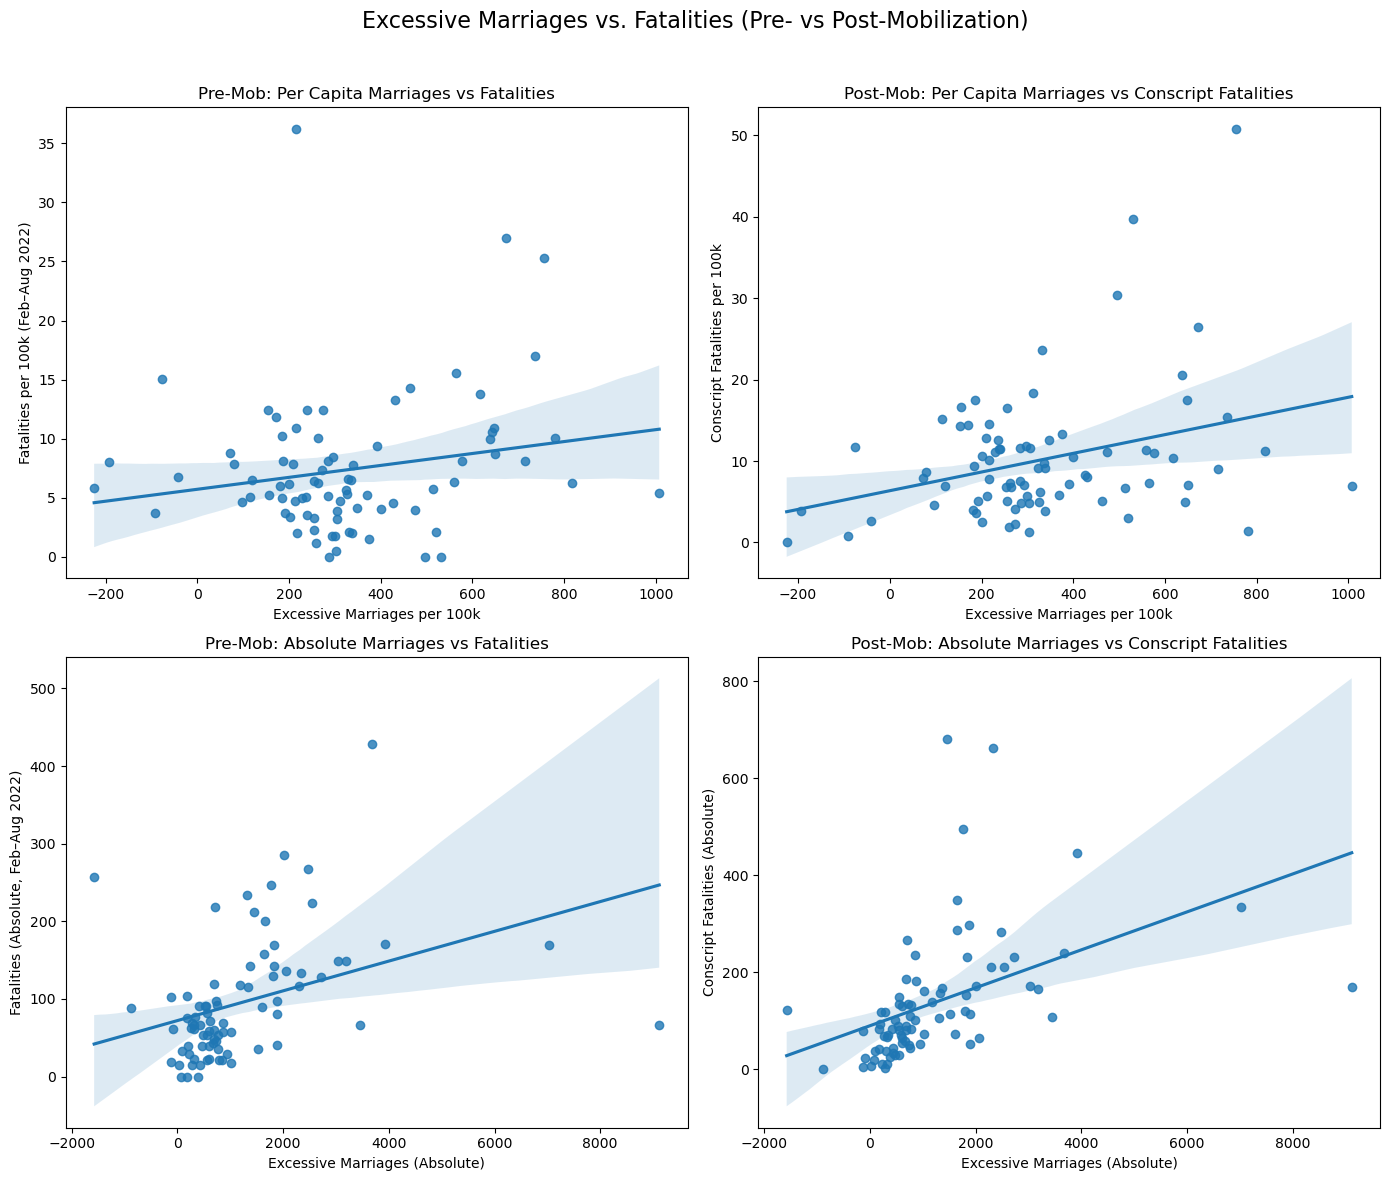

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Excessive Marriages vs. Fatalities (Pre- vs Post-Mobilization)', fontsize=16)

sns.regplot(data=merged, x='ex_nup_per100k', y='pre_total_per_100k', ax=axes[0, 0])
axes[0, 0].set_title('Pre-Mob: Per Capita Marriages vs Fatalities')
axes[0, 0].set_xlabel('Excessive Marriages per 100k')
axes[0, 0].set_ylabel('Fatalities per 100k (Feb–Aug 2022)')

sns.regplot(data=merged, x='ex_nup_per100k', y='drafted_per_100k', ax=axes[0, 1])
axes[0, 1].set_title('Post-Mob: Per Capita Marriages vs Conscript Fatalities')
axes[0, 1].set_xlabel('Excessive Marriages per 100k')
axes[0, 1].set_ylabel('Conscript Fatalities per 100k')

sns.regplot(data=merged, x='Excessive Marriages', y='pre_total_abs', ax=axes[1, 0])
axes[1, 0].set_title('Pre-Mob: Absolute Marriages vs Fatalities')
axes[1, 0].set_xlabel('Excessive Marriages (Absolute)')
axes[1, 0].set_ylabel('Fatalities (Absolute, Feb–Aug 2022)')

sns.regplot(data=merged, x='Excessive Marriages', y='drafted', ax=axes[1, 1])
axes[1, 1].set_title('Post-Mob: Absolute Marriages vs Conscript Fatalities')
axes[1, 1].set_xlabel('Excessive Marriages (Absolute)')
axes[1, 1].set_ylabel('Conscript Fatalities (Absolute)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
